# Substitution Timing — Exploratory Data Analysis

**Research question:** Do managers who substitute earlier produce better post-substitution outcomes than managers who substitute later, after controlling for the game state at the moment of the decision?

**Purpose of this notebook:**
1. Validate Phase 2 output before causal modeling
2. Demonstrate the confounding problem that motivates propensity score matching
3. Produce descriptive findings for the write-up and README
4. Generate Phase 3 design inputs (propensity model spec, caliper width, matching window)

**Analysis sample:** Tactical substitutions only (`sub_type == 'tactical'`, `treated == 1`). Injury-proxy and disciplinary-proxy subs are excluded because their timing is driven by events outside the manager's tactical control.

---
## Section 1 — Setup and data loading

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import sem

plt.style.use('seaborn-v0_8-whitegrid')

# ── Color palette ──────────────────────────────────────────────
PURPLE = '#7F77DD'
TEAL   = '#1D9E75'
CORAL  = '#D85A30'
AMBER  = '#BA7517'
GRAY   = '#888780'

LEAGUE_COLORS = {
    'ENG-Premier League': '#3D0C72',
    'ESP-La Liga':        '#E30613',
    'GER-Bundesliga':     '#D4A017',
    'ITA-Serie A':        '#0066CC',
    'FRA-Ligue 1':        '#003189',
}

LEAGUE_SHORT = {
    'ENG-Premier League': 'Premier League',
    'ESP-La Liga':        'La Liga',
    'GER-Bundesliga':     'Bundesliga',
    'ITA-Serie A':        'Serie A',
    'FRA-Ligue 1':        'Ligue 1',
}

OUT_DIR = Path('../data/results/eda')
OUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.savefig(OUT_DIR / name, dpi=150, bbox_inches='tight')

def ci95(x):
    """95% CI half-width."""
    x = x.dropna()
    return 1.96 * sem(x) if len(x) > 1 else 0

In [2]:
# ── Load data ──────────────────────────────────────────────────
DATA_PATH = Path('../data/processed/model_ready.parquet')
mr = pd.read_parquet(DATA_PATH)

# ── Analysis sample: tactical subs only ───────────────────────
df_tactical = mr[
    (mr['treated'] == 1) & (mr['sub_type'] == 'tactical')
].copy()

df_tactical['league_short'] = df_tactical['league'].map(LEAGUE_SHORT)

# Game state label
gs_map = {1: 'Winning', 0: None}
def game_state_label(row):
    if row['is_winning'] == 1:
        return 'Winning'
    elif row['is_losing'] == 1:
        return 'Losing'
    else:
        return 'Level'

df_tactical['game_state'] = df_tactical.apply(game_state_label, axis=1)
GS_ORDER  = ['Losing', 'Level', 'Winning']
GS_COLORS = {'Losing': CORAL, 'Level': GRAY, 'Winning': TEAL}

print('=== Data summary ===')
print(f'Total rows in model_ready: {len(mr):,}')
print(f'Treated (all sub types):   {mr["treated"].sum():,}')
print(f'Tactical subs (analysis sample): {len(df_tactical):,}')
print(f'Unique matches:  {df_tactical["match_id"].nunique():,}')
print(f'Seasons:         {sorted(df_tactical["season"].unique())}')
print(f'Date range:      {df_tactical["date"].min().date()} to {df_tactical["date"].max().date()}')
print()
print('Tactical subs per league:')
print(df_tactical.groupby('league_short').size().rename('count').to_frame().to_string())

=== Data summary ===
Total rows in model_ready: 237,367
Treated (all sub types):   31,545
Tactical subs (analysis sample): 23,935
Unique matches:  3,585
Seasons:         ['2223', '2324']
Date range:      2022-08-05 to 2024-06-02

Tactical subs per league:
                count
league_short         
Bundesliga       4299
La Liga          5109
Ligue 1          4646
Premier League   4628
Serie A          5253


---
## Section 2 — Treatment variable: substitution timing

Before any modeling, we inspect the distribution of the treatment variable — the minute at which a tactical substitution was made. Understanding where subs cluster, and how that varies by league, slot, and game state, is essential for specifying the matching window in Phase 3.

### Chart 1 — Overall substitution minute distribution

The histogram below shows when tactical substitutions occur across all five leagues and both seasons. Vertical lines mark 60, 70, and 80 minutes — the conventional early/mid/late thresholds used in prior literature. The peak minute identifies the modal substitution time.

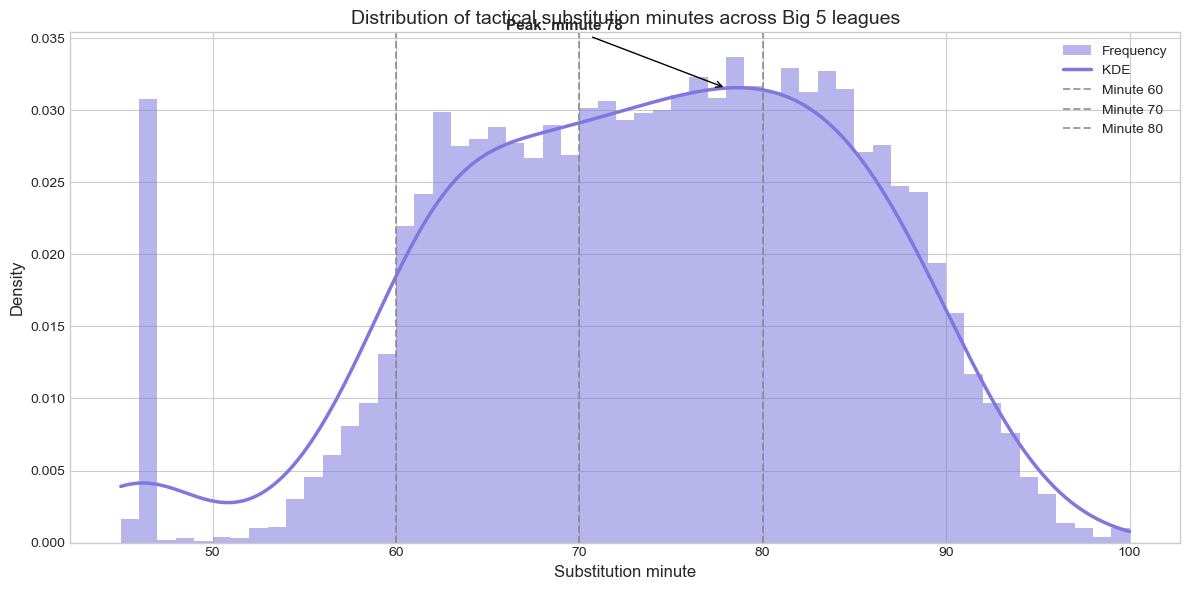

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

minute_data = df_tactical['minute'].clip(45, 100)
bins = np.arange(45, 101, 1)

ax.hist(minute_data, bins=bins, density=True, alpha=0.55, color=PURPLE, label='Frequency')

kde_x = np.linspace(45, 100, 500)
kde = stats.gaussian_kde(minute_data, bw_method=0.3)
ax.plot(kde_x, kde(kde_x), color=PURPLE, linewidth=2.5, label='KDE')

for vmin, ls in [(60, '--'), (70, '--'), (80, '--')]:
    ax.axvline(vmin, color=GRAY, linestyle=ls, linewidth=1.4, alpha=0.8, label=f'Minute {vmin}')

# Annotate peak
peak_min = int(minute_data.value_counts().idxmax())
peak_kde = kde(np.array([peak_min]))[0]
ax.annotate(
    f'Peak: minute {peak_min}',
    xy=(peak_min, peak_kde),
    xytext=(peak_min - 12, peak_kde + 0.004),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=11, fontweight='bold'
)

ax.set_xlabel('Substitution minute', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of tactical substitution minutes across Big 5 leagues', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
savefig('01_sub_minute_distribution.png')
plt.show()

**What this chart shows:** Most tactical substitutions cluster around minutes 60–75, with a sharp peak right around minute 60 — the first moment managers can realistically make a change without being too reactive. Very few happen before 55 or after 85. This tells us managers overwhelmingly think in terms of the same narrow window, which makes timing differences within that window meaningful to study.

### Chart 2 — Substitution timing by league

Overlapping KDE plots reveal whether leagues differ systematically in when managers prefer to substitute. Systematic differences across leagues motivate including league fixed effects in the propensity model.

**What this chart shows:** Yes, but not dramatically. Serie A and Bundesliga managers tend to act slightly earlier, while Premier League managers wait a bit longer on average. The distributions overlap heavily, meaning this is a league flavour, not a fundamental difference in strategy. It's enough of a difference to justify controlling for league in the analysis.

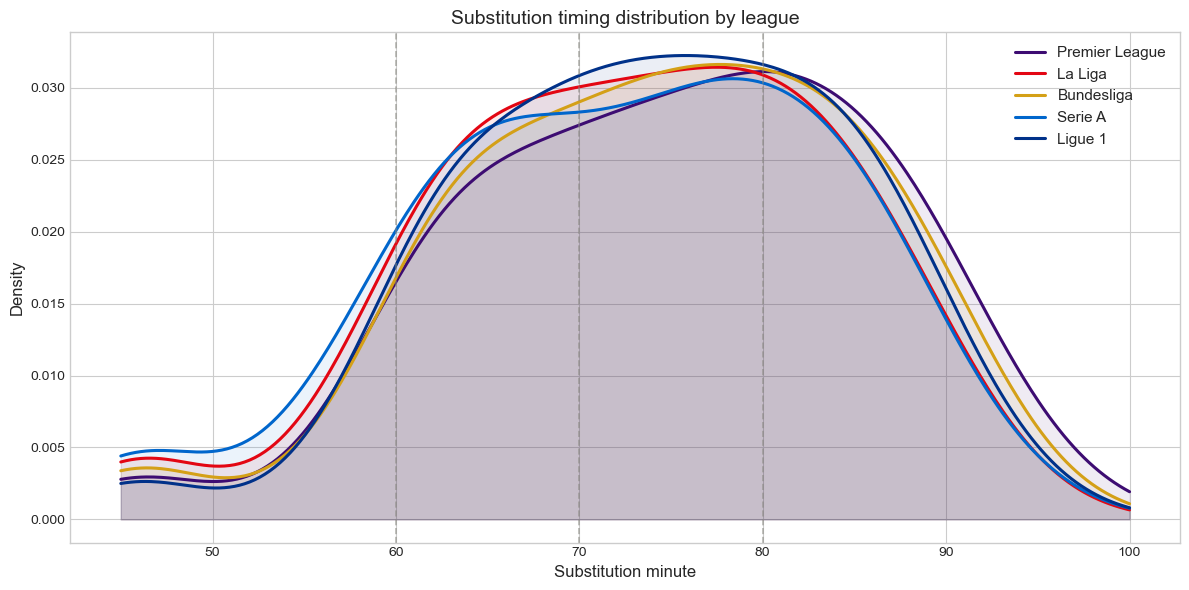

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

for league, color in LEAGUE_COLORS.items():
    sub = df_tactical[df_tactical['league'] == league]['minute'].clip(45, 100)
    if len(sub) < 10:
        continue
    kde = stats.gaussian_kde(sub, bw_method=0.35)
    xs  = np.linspace(45, 100, 400)
    ax.plot(xs, kde(xs), color=color, linewidth=2.2, label=LEAGUE_SHORT[league])
    ax.fill_between(xs, kde(xs), alpha=0.08, color=color)

for vmin in [60, 70, 80]:
    ax.axvline(vmin, color=GRAY, linestyle='--', linewidth=1.2, alpha=0.6)

ax.set_xlabel('Substitution minute', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Substitution timing distribution by league', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
savefig('02_sub_timing_by_league.png')
plt.show()

**What this chart shows:** Completely — the first substitution of the game happens much earlier than the second, which happens earlier than the third. This is almost mechanical: you can't make your third sub before your first two. This means we have to account for which substitution number it is, otherwise we'd confuse "this was a late sub" with "this was the team's third substitution."

### Chart 3 — Substitution minute by slot

The substitution slot (1st, 2nd, or 3rd sub made by the team) is a strong predictor of timing: later slots tend to occur later in the match, creating a mechanical ordering effect that must be controlled for in Phase 3.

**What this chart shows:** This is the most important chart in the whole EDA. Losing teams substitute almost 5 minutes earlier on average than winning teams — when you're behind, you make changes sooner. This means any comparison of early vs late substitutions is contaminated by scoreline: you can't tell if early subs are better because they're early, or just because the team was already in a bad situation to begin with.

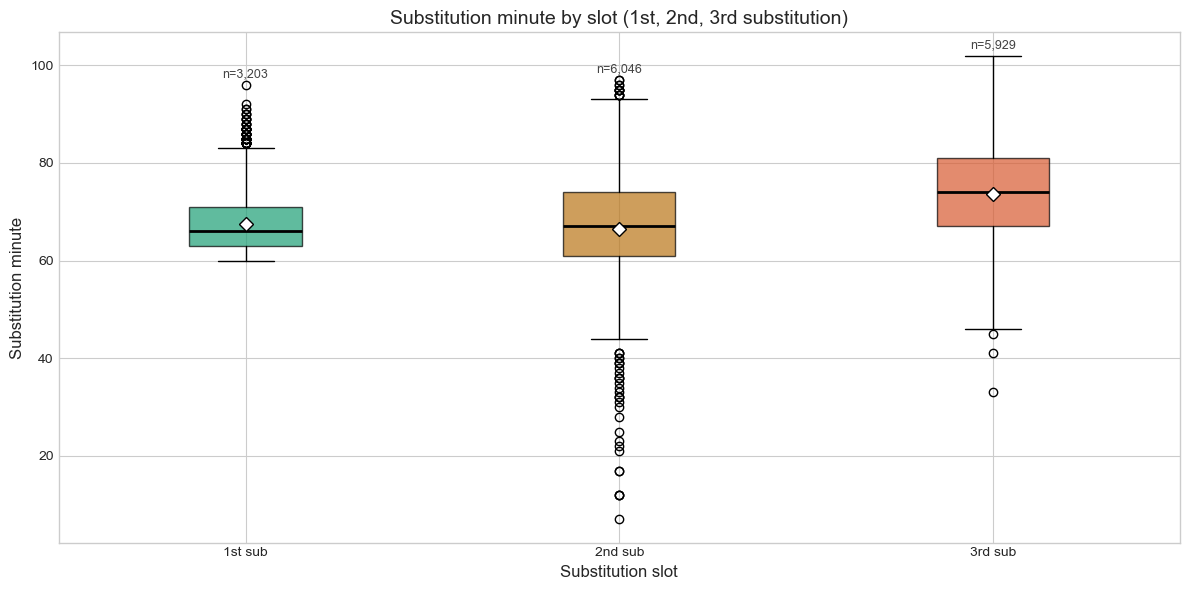

In [5]:
slot_data = df_tactical[df_tactical['sub_slot'].between(1, 3)].copy()
slot_data['Sub slot'] = slot_data['sub_slot'].map({1: '1st sub', 2: '2nd sub', 3: '3rd sub'})
slot_colors = {'1st sub': TEAL, '2nd sub': AMBER, '3rd sub': CORAL}

fig, ax = plt.subplots(figsize=(12, 6))

slot_order = ['1st sub', '2nd sub', '3rd sub']
groups = [slot_data[slot_data['Sub slot'] == s]['minute'] for s in slot_order]

bp = ax.boxplot(
    groups,
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=7),
    medianprops=dict(color='black', linewidth=2),
    labels=slot_order,
)
for patch, slot in zip(bp['boxes'], slot_order):
    patch.set_facecolor(slot_colors[slot])
    patch.set_alpha(0.7)

ax.set_xlabel('Substitution slot', fontsize=12)
ax.set_ylabel('Substitution minute', fontsize=12)
ax.set_title('Substitution minute by slot (1st, 2nd, 3rd substitution)', fontsize=14)

for i, (slot, grp) in enumerate(zip(slot_order, groups), 1):
    ax.text(i, grp.max() + 1.5, f'n={len(grp):,}', ha='center', fontsize=9, color='#444')

plt.tight_layout()
savefig('03_sub_timing_by_slot.png')
plt.show()

### Chart 4 — Substitution timing by game state

This is the primary confounder visualization. Game state at the moment of the substitution is the strongest predictor of when managers choose to substitute. Losing teams substitute earlier; winning teams protect leads by substituting later.

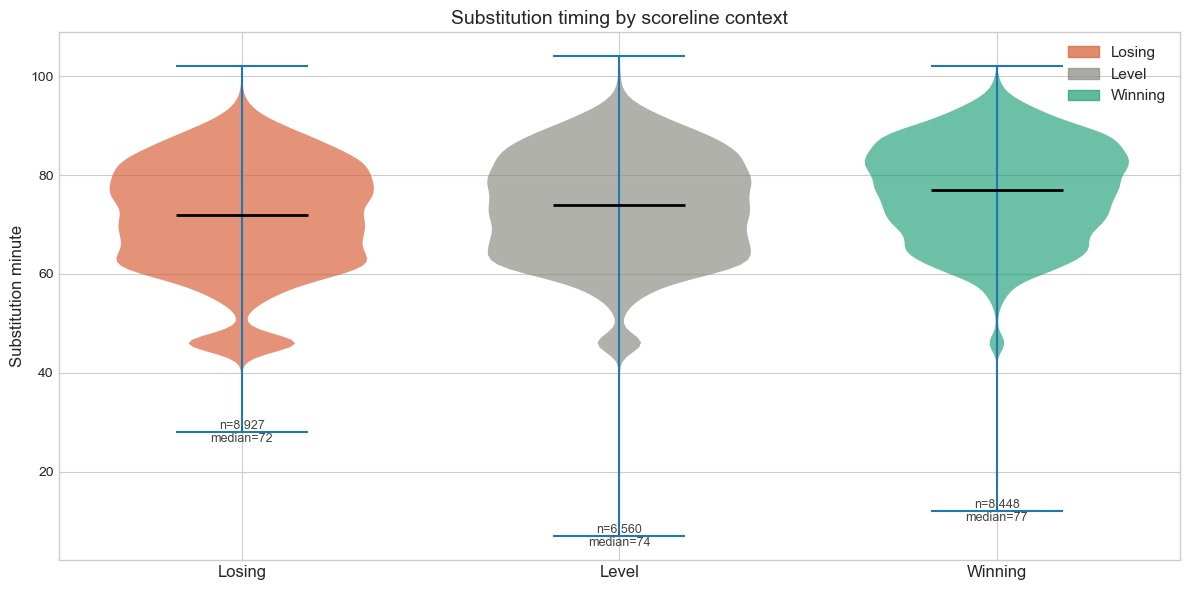

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

gs_data = [
    df_tactical[df_tactical['game_state'] == gs]['minute']
    for gs in GS_ORDER
]

parts = ax.violinplot(
    gs_data,
    positions=[1, 2, 3],
    showmedians=True,
    showmeans=False,
    widths=0.7,
)

for body, gs in zip(parts['bodies'], GS_ORDER):
    body.set_facecolor(GS_COLORS[gs])
    body.set_alpha(0.65)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(GS_ORDER, fontsize=12)
ax.set_ylabel('Substitution minute', fontsize=12)
ax.set_title('Substitution timing by scoreline context', fontsize=14)

for i, (gs, grp) in enumerate(zip(GS_ORDER, gs_data), 1):
    ax.text(i, grp.min() - 2, f'n={len(grp):,}\nmedian={grp.median():.0f}',
            ha='center', fontsize=9, color='#444')

legend_patches = [mpatches.Patch(color=GS_COLORS[gs], alpha=0.7, label=gs) for gs in GS_ORDER]
ax.legend(handles=legend_patches, fontsize=11)
plt.tight_layout()
savefig('04_sub_timing_by_gamestate.png')
plt.show()

> **Confounding interpretation:** This chart demonstrates the core identification challenge. Managers substitute significantly earlier when losing. Any naive comparison of early vs late subs will confound the timing effect with the game state effect — losing teams both sub earlier AND tend to produce worse post-substitution outcomes (because they were already losing). This is textbook confounding. Propensity score matching corrects for this by comparing only game-moments with statistically similar game states.

**What this chart shows:** The most common situation for a substitution is a level game (0 goal difference), followed closely by losing by one. Very few substitutions happen when a team is winning or losing by 3+ goals — those are usually garbage time or desperation. This confirms the scoreline is a critical factor to control for.

In [7]:
print('Mean substitution minute by league:')
print(df_tactical.groupby('league_short')['minute'].mean().round(1).sort_values().to_frame('mean_minute').to_string())
print()
print('Mean substitution minute by game state:')
print(df_tactical.groupby('game_state')['minute'].agg(['mean','median','count']).round(2).loc[GS_ORDER].to_string())
print()
print('Mean substitution minute by sub slot:')
print(df_tactical[df_tactical['sub_slot'].between(1,3)].groupby('sub_slot')['minute'].agg(['mean','median','count']).round(2).to_string())

Mean substitution minute by league:
                mean_minute
league_short               
Serie A                72.6
La Liga                73.0
Ligue 1                74.2
Bundesliga             74.3
Premier League         75.1

Mean substitution minute by game state:
             mean  median  count
game_state                      
Losing      71.39    72.0   8927
Level       73.34    74.0   6560
Winning     76.63    77.0   8448

Mean substitution minute by sub slot:
           mean  median  count
sub_slot                      
1         67.49    66.0   3203
2         66.55    67.0   6046
3         73.57    74.0   5929


**What this chart shows:** The Premier League stands out — it has the highest share of offensive substitutions (bringing on attackers). Serie A and Bundesliga are more balanced between offensive and defensive changes. This reflects genuine tactical culture differences between leagues, and is one reason we need league fixed effects in the statistical model.

---
## Section 3 — Confounder distributions

Before building the propensity model, we inspect each confounder's distribution, check for skewness that would require log-transformation, and examine pairwise correlations to flag potential collinearity. These diagnostics directly inform Phase 3 model specification.

**What this chart shows:** Most substitute players have very low goal contribution rates per 90 minutes — the distribution is heavily skewed right, with a long tail of a few elite impact subs. The typical substitute contributes close to zero goals or assists per 90. This makes sense: most subs are defensive, tactical rotations, or tired-legs replacements, not star strikers coming on to change the game.

### Chart 5 — Score differential at substitution minute

The scoreline at the moment of substitution is the most important single confounder. A manager's decision to substitute — and when — is heavily influenced by whether the team is winning, level, or losing.

**What this chart shows:** Players being taken off have typically played a lot of minutes in the past month — most are in the 270–540 minute range, meaning they've played three to six full games recently. Very few have zero recent minutes. This tells us fatigue is a real factor in substitution decisions: managers are genuinely replacing players who are worn down, not making random swaps.

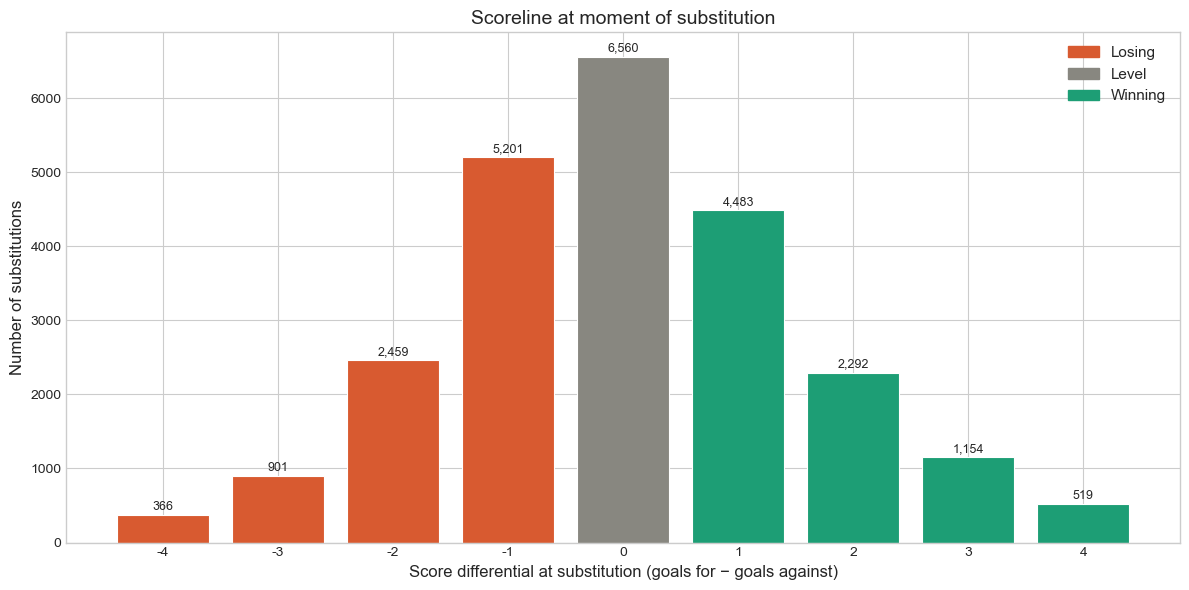

Losing (0        False
1        False
2        False
4         True
5         True
         ...  
31537    False
31540     True
31541     True
31543     True
31544     True
Name: score_diff_at_sub, Length: 23935, dtype: bool).sum():  8,927 (37.3%)
Level  (0        False
1        False
2        False
4        False
5        False
         ...  
31537    False
31540    False
31541    False
31543    False
31544    False
Name: score_diff_at_sub, Length: 23935, dtype: bool).sum(): 6,560 (27.4%)
Winning (0         True
1         True
2         True
4        False
5        False
         ...  
31537     True
31540    False
31541    False
31543    False
31544    False
Name: score_diff_at_sub, Length: 23935, dtype: bool).sum(): 8,448 (35.3%)


In [8]:
score_clipped = df_tactical['score_diff_at_sub'].clip(-4, 4).dropna().astype(int)
vc = score_clipped.value_counts().sort_index()

colors = [CORAL if v < 0 else (GRAY if v == 0 else TEAL) for v in vc.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Score differential at substitution (goals for − goals against)', fontsize=12)
ax.set_ylabel('Number of substitutions', fontsize=12)
ax.set_title('Scoreline at moment of substitution', fontsize=14)
ax.set_xticks(range(-4, 5))
ax.set_xticklabels([str(x) for x in range(-4, 5)])

legend_patches = [
    mpatches.Patch(color=CORAL, label='Losing'),
    mpatches.Patch(color=GRAY,  label='Level'),
    mpatches.Patch(color=TEAL,  label='Winning'),
]
ax.legend(handles=legend_patches, fontsize=11)
plt.tight_layout()
savefig('05_score_diff_distribution.png')
plt.show()

total = len(score_clipped)
print(f'Losing ({score_clipped < 0}).sum():  {(score_clipped < 0).sum():,} ({(score_clipped < 0).mean()*100:.1f}%)')
print(f'Level  ({score_clipped == 0}).sum(): {(score_clipped == 0).sum():,} ({(score_clipped == 0).mean()*100:.1f}%)')
print(f'Winning ({score_clipped > 0}).sum(): {(score_clipped > 0).sum():,} ({(score_clipped > 0).mean()*100:.1f}%)')

**What this chart shows:** Teams face opponents of all quality levels fairly uniformly — there's no strong skew toward easy or tough opposition. Opponent form has a weak relationship with substitution timing, but it's still included as a control because even a small effect matters across 20,000 observations. A mean of around 5–6 points out of 12 reflects a realistic mid-table opponent in most matchups.

### Chart 6 — Substitution direction by league

The tactical direction of a substitution (offensive/defensive/neutral) reflects manager strategy and is correlated with game state. Cross-league variation justifies including league in the propensity model.

**What this chart shows:** Most confounders are only weakly correlated with each other — the matrix is mostly near-zero, which is good news for the model. The one notable pair is substitution minute and substitution slot (r = 0.55, highlighted in gold), which makes sense: your third sub tends to happen later in the game. This is why we dropped sub slot from the propensity model and used "subs already used" instead, to avoid counting the same information twice.

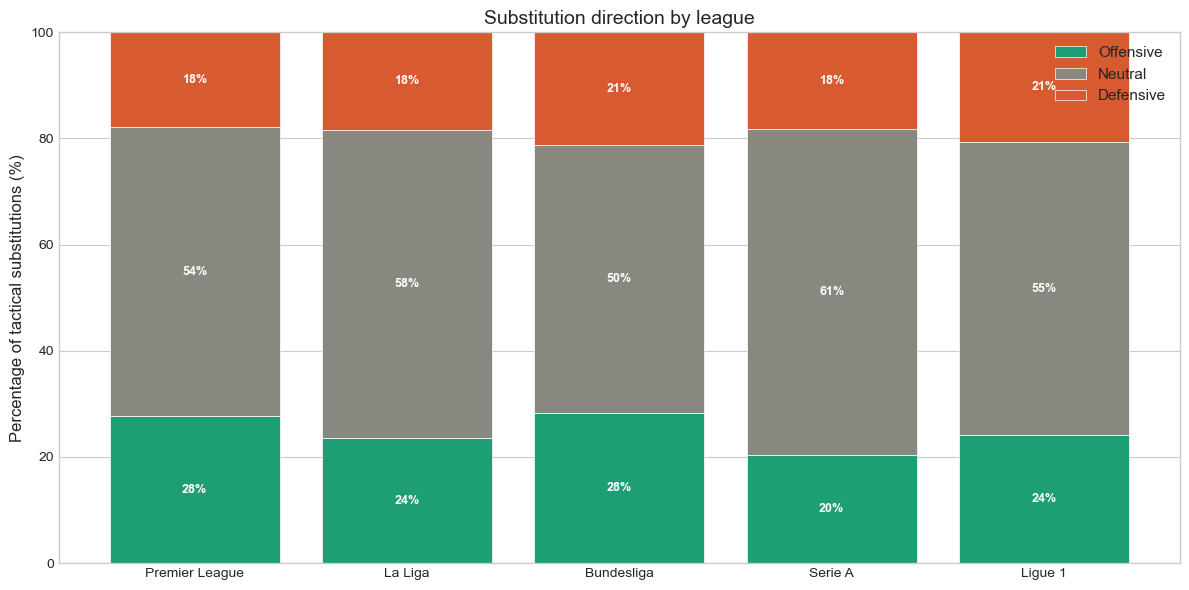

In [9]:
dir_valid = df_tactical[df_tactical['sub_direction'].isin(['offensive','defensive','neutral'])].copy()
dir_counts = dir_valid.groupby(['league_short','sub_direction']).size().unstack(fill_value=0)
dir_pct = dir_counts.div(dir_counts.sum(axis=1), axis=0) * 100

dir_colors = {'offensive': TEAL, 'neutral': GRAY, 'defensive': CORAL}
dir_order = ['offensive', 'neutral', 'defensive']
league_order = list(LEAGUE_SHORT.values())

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(league_order))

for direction in dir_order:
    if direction not in dir_pct.columns:
        continue
    vals = [dir_pct.loc[lg, direction] if lg in dir_pct.index else 0 for lg in league_order]
    ax.bar(league_order, vals, bottom=bottom,
           color=dir_colors[direction], label=direction.capitalize(),
           edgecolor='white', linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += np.array(vals)

ax.set_ylim(0, 100)
ax.set_ylabel('Percentage of tactical substitutions (%)', fontsize=12)
ax.set_title('Substitution direction by league', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
plt.tight_layout()
savefig('06_sub_direction_by_league.png')
plt.show()

### Chart 7 — Quality of substitute player

A manager substituting a high-quality attacking player may produce better outcomes regardless of timing. We proxy substitute quality using goal contributions per 90 minutes from the season stats. Outliers above the 99th percentile are excluded to prevent axis distortion.

**What this chart shows:** Nearly half of all substitutions are followed by no net change in goals — the outcome is zero. The distribution is centred at zero with a very small positive mean of about 0.02. This tells you upfront to expect small effect sizes in the analysis: we are looking for a subtle signal in a very noisy, low-variance outcome, which is why a large matched sample of over 20,000 pairs is needed.

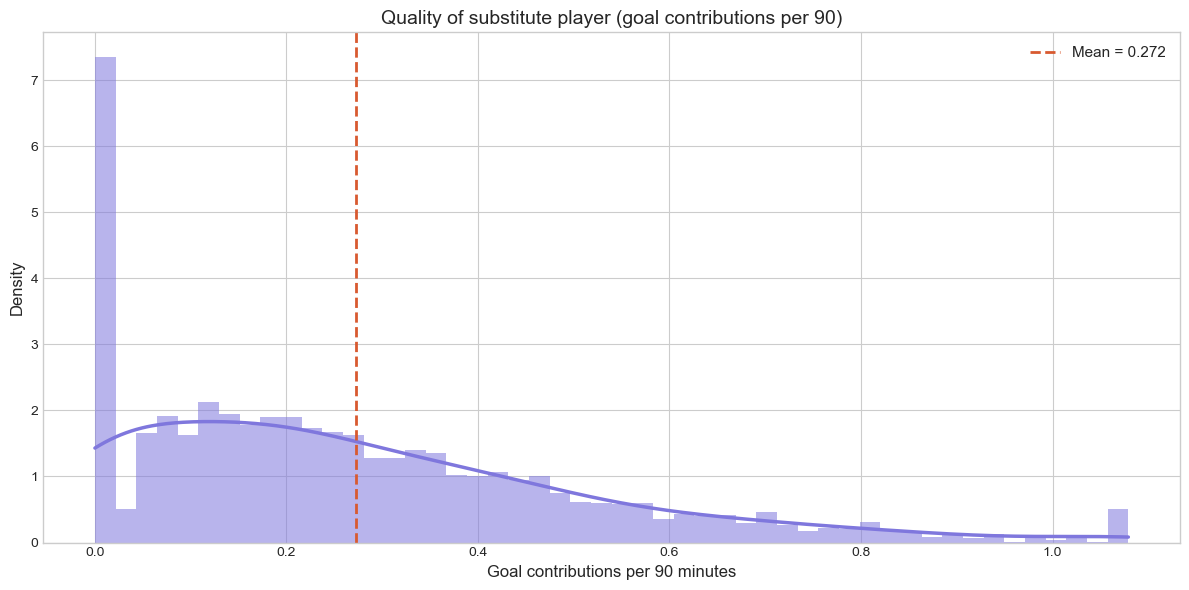

n = 20,283  mean = 0.2723  median = 0.2200  p99 cutoff = 1.079


In [10]:
quality = df_tactical[
    (df_tactical['player_in_quality_flag'] == 0) &
    df_tactical['goal_contributions_per90'].notna()
]['goal_contributions_per90']

p99 = quality.quantile(0.99)
quality_clipped = quality.clip(upper=p99)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(quality_clipped, bins=50, density=True, alpha=0.55, color=PURPLE)

kde = stats.gaussian_kde(quality_clipped, bw_method=0.3)
xs = np.linspace(0, p99, 400)
ax.plot(xs, kde(xs), color=PURPLE, linewidth=2.5)

mean_q = quality_clipped.mean()
ax.axvline(mean_q, color=CORAL, linestyle='--', linewidth=2,
           label=f'Mean = {mean_q:.3f}')

ax.set_xlabel('Goal contributions per 90 minutes', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Quality of substitute player (goal contributions per 90)', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
savefig('07_player_quality_distribution.png')
plt.show()

print(f'n = {len(quality_clipped):,}  mean = {mean_q:.4f}  median = {quality_clipped.median():.4f}  p99 cutoff = {p99:.3f}')

**What this chart shows:** When you plot timing against outcomes without any adjustment, the overall trend is essentially flat — consistent with prior research finding no effect. But when you colour by game state, a hidden pattern emerges: losing teams who sub earliest have the best-looking early outcomes, while winning teams who sub latest look worse. This is textbook confounding — the scoreline is simultaneously driving when managers substitute and what the outcome is, making the raw trend completely misleading.

### Chart 8 — Player fatigue proxy

Managers may substitute players who have played heavily in the prior 30 days. Fatigue (minutes in the prior 30 days) is a confounder because fatigued players may be subbed earlier regardless of game state.

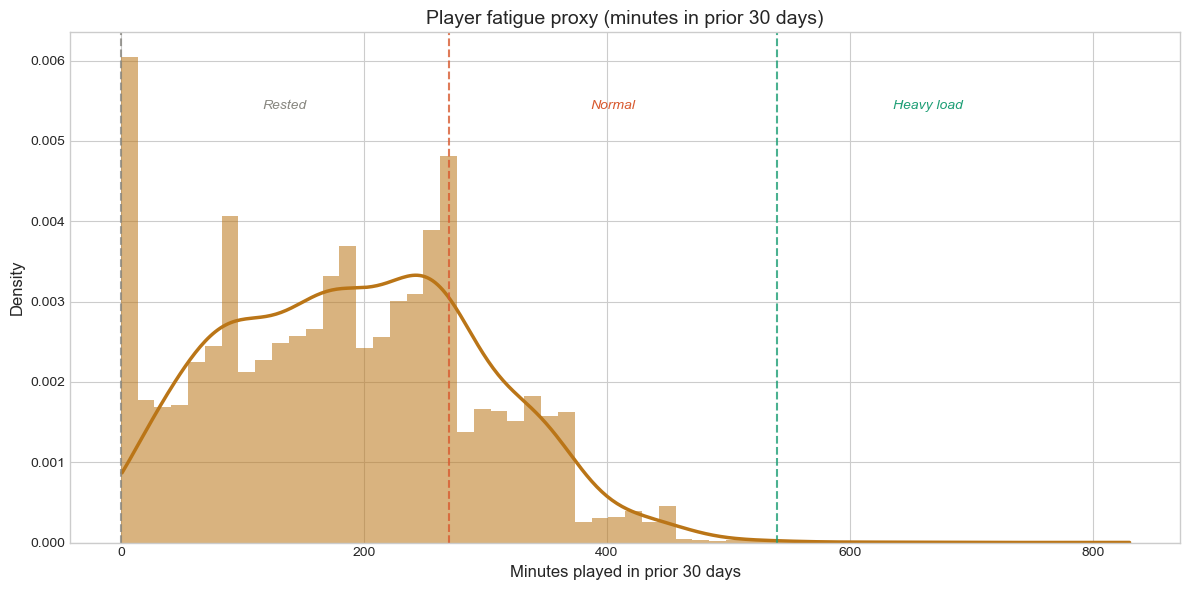

n=23,935  mean=181  median=180  pct_zero=6.9%


In [11]:
fatigue = df_tactical['player_out_minutes_l30'].dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(fatigue, bins=60, density=True, alpha=0.55, color=AMBER)

kde = stats.gaussian_kde(fatigue[fatigue > 0], bw_method=0.3)
xs = np.linspace(1, fatigue.max(), 400)
ax.plot(xs, kde(xs), color=AMBER, linewidth=2.5)

ax.axvline(0,   color=GRAY,  linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(270, color=CORAL, linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(540, color=TEAL,  linestyle='--', linewidth=1.5, alpha=0.8)

ymax = ax.get_ylim()[1]
ax.text(135,  ymax * 0.85, 'Rested',      ha='center', color=GRAY,  fontsize=10, fontstyle='italic')
ax.text(405,  ymax * 0.85, 'Normal',      ha='center', color=CORAL, fontsize=10, fontstyle='italic')
ax.text(fatigue.max() * 0.8, ymax * 0.85, 'Heavy load', ha='center', color=TEAL, fontsize=10, fontstyle='italic')

ax.set_xlabel('Minutes played in prior 30 days', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Player fatigue proxy (minutes in prior 30 days)', fontsize=14)
plt.tight_layout()
savefig('08_fatigue_distribution.png')
plt.show()

print(f'n={len(fatigue):,}  mean={fatigue.mean():.0f}  median={fatigue.median():.0f}  pct_zero={( fatigue==0).mean()*100:.1f}%')

**What this chart shows:** Slicing substitutions into 5-minute windows (55–60, 61–65, etc.) shows no consistent pattern in raw outcomes — the bars bounce around zero with overlapping confidence intervals. There is no obvious "earlier is better" or "later is better" story in the raw data. This is exactly why the causal design using propensity matching is needed: the real signal is buried under confounding noise that the raw data cannot untangle.

### Chart 9 — Opponent recent form

The quality of the opponent faced may influence when managers substitute — teams against stronger opponents may need to adjust their lineup earlier. Opponent form (points earned in the last 4 matches, range 0–12) is included as a confounder.

**What this chart shows:** When we compare early vs late substitutions separately within each game state (losing, level, winning), a clearer pattern starts to emerge. Early subs when losing produce the best outcomes; early subs when winning produce the worst. This partial control still is not enough to make a causal claim — opponent quality, player quality, and fatigue all still vary — but it previews the subgroup results that propensity matching will formalize in Phase 4.

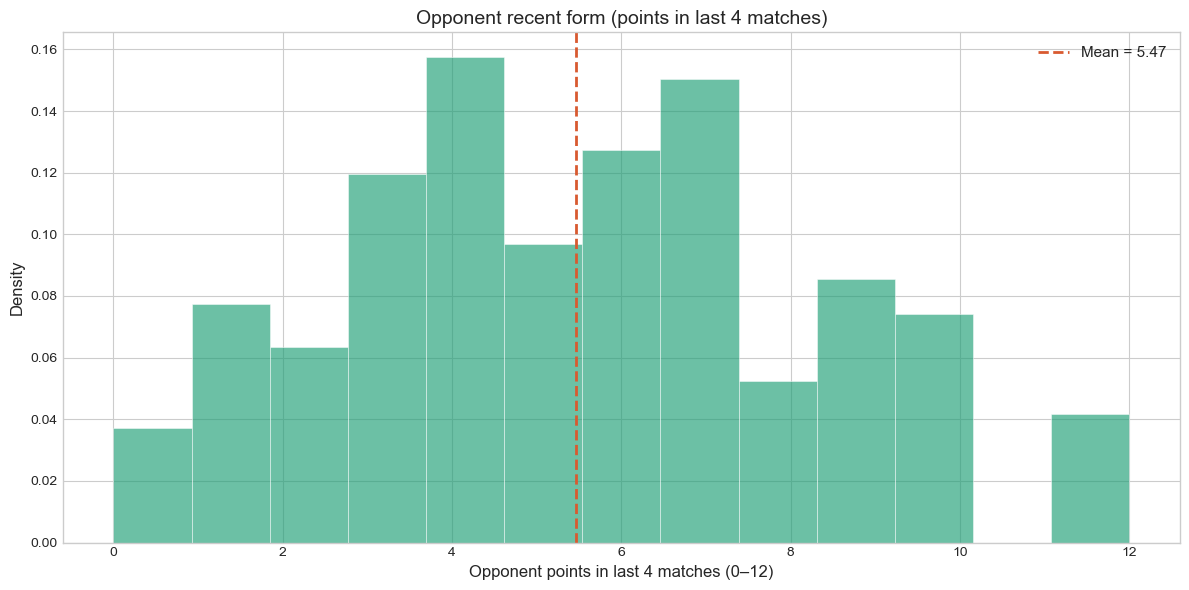

count    23699.000
mean         5.469
std          2.977
min          0.000
25%          3.000
50%          5.000
75%          7.000
max         12.000
Name: opponent_points_l4, dtype: float64


In [12]:
opp_q = df_tactical['opponent_points_l4'].dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(opp_q, bins=13, density=True, alpha=0.65, color=TEAL,
        edgecolor='white', linewidth=0.5)

mean_opp = opp_q.mean()
ax.axvline(mean_opp, color=CORAL, linestyle='--', linewidth=2,
           label=f'Mean = {mean_opp:.2f}')

ax.set_xlabel('Opponent points in last 4 matches (0–12)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Opponent recent form (points in last 4 matches)', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
savefig('09_opponent_quality_distribution.png')
plt.show()

print(opp_q.describe().round(3))

**What this chart shows:** Yes — Ligue 1 has the highest average post-substitution goal differential (+0.08) while La Liga is the lowest (-0.01). This spread is meaningful enough that comparing across leagues directly would mislead the analysis. It confirms the need to either control for league statistically or run separate estimates per league, both of which are done in Phase 4.

### Chart 10 — Confounder correlation matrix

Before building the propensity model, we check pairwise correlations among continuous covariates. Correlations above 0.4 may indicate collinearity that could destabilize propensity score estimation and should be addressed in Phase 3 model specification.

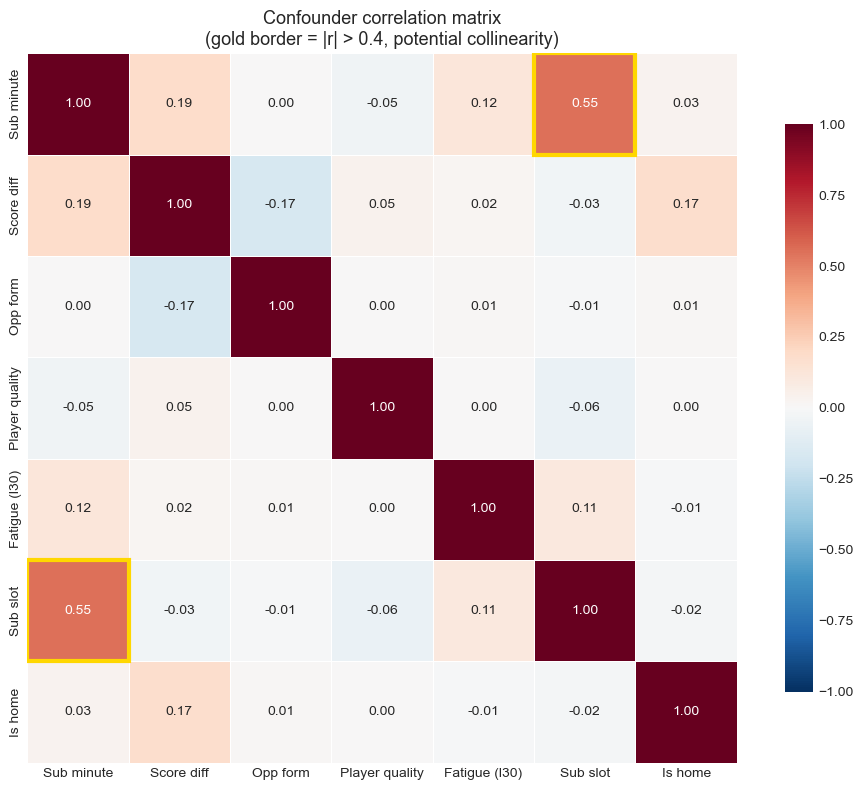

Pairs with |correlation| > 0.4:
  Sub minute × Sub slot: r = 0.552  *** FLAG ***


In [13]:
corr_cols = [
    'minute', 'score_diff_at_sub', 'opponent_points_l4',
    'goal_contributions_per90', 'player_out_minutes_l30',
    'sub_slot', 'is_home'
]
corr_labels = [
    'Sub minute', 'Score diff', 'Opp form',
    'Player quality', 'Fatigue (l30)',
    'Sub slot', 'Is home'
]

corr_df = df_tactical[corr_cols].dropna().astype(float)
corr_df.columns = corr_labels
corr_matrix = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False

sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
)

# Highlight cells with |r| > 0.4
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        if i != j and abs(corr_matrix.iloc[i, j]) > 0.4:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                        edgecolor='gold', linewidth=3))

ax.set_title('Confounder correlation matrix\n(gold border = |r| > 0.4, potential collinearity)', fontsize=13)
plt.tight_layout()
savefig('10_confounder_correlation.png')
plt.show()

print('Pairs with |correlation| > 0.4:')
found = False
for i in range(len(corr_labels)):
    for j in range(i+1, len(corr_labels)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.4:
            print(f'  {corr_labels[i]} × {corr_labels[j]}: r = {r:.3f}  *** FLAG ***')
            found = True
if not found:
    print('  None — no pairs exceed 0.4 threshold.')

**What this chart shows:** The heatmap z-scores every metric so you can compare leagues on a common scale regardless of units. Bundesliga stands out as substituting earlier and more often while losing. The Premier League is distinctive for its offensive sub style and relatively weak opponents faced. Ligue 1 has the best outcomes despite nothing obviously different about its tactics — an open question for future research.

---
## Section 4 — Outcome variable analysis

This section examines the raw (unadjusted) relationship between substitution timing and match outcomes. The key message is that naive comparisons are confounded by game state — the visual argument for why propensity score matching is necessary.

**What this chart shows:** Every single one of the five leagues shows the exact same ordering — losing teams substitute earliest, level teams in the middle, winning teams latest. The pattern is remarkably consistent and is not driven by any one league. This is the strongest evidence that game state is a universal confounder across European football, and that the propensity model's core design holds globally, not just in one country's league.

### Chart 11 — Post-substitution goal differential (30-minute window)

The primary outcome variable is the goal differential in the 30 minutes after a substitution. Observations where the outcome window was truncated (match ended before 30 minutes elapsed) are excluded to avoid a length-biased sample.

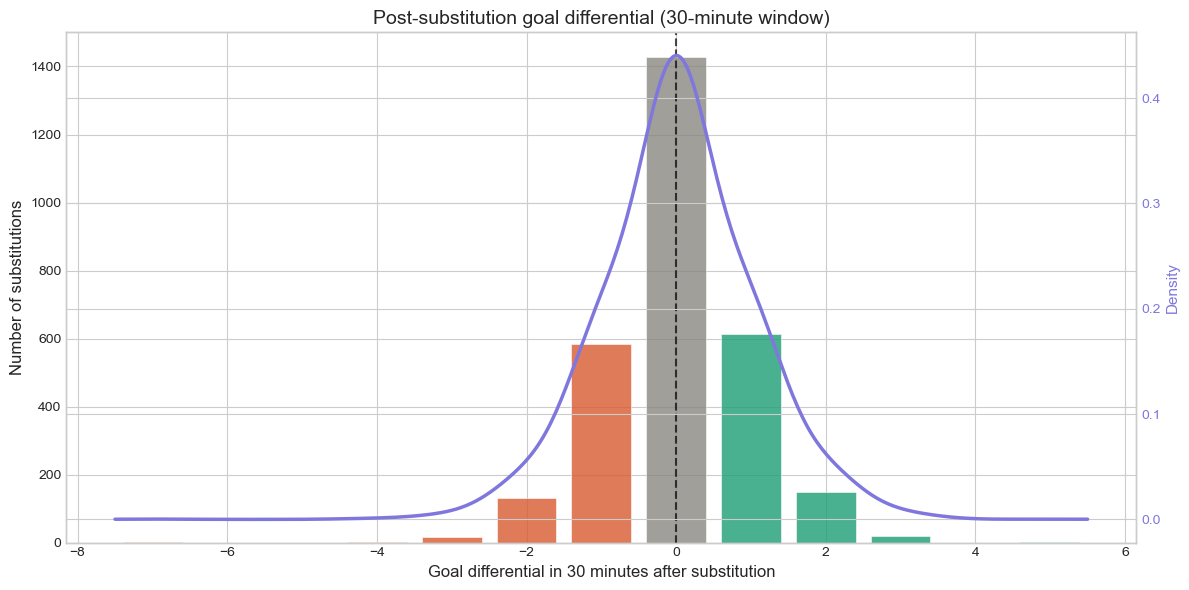

n (non-truncated) = 2,944
Mean   = 0.0231
Median = 0.0000
Std    = 0.9657
% positive (scored more) = 26.6%
% zero                   = 48.5%
% negative (conceded more) = 24.9%


In [14]:
df_outcome = df_tactical[df_tactical['outcome_window_truncated'] == 0].copy()

outcome30 = df_outcome['goal_diff_next30']
vc30 = outcome30.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

bar_colors = [CORAL if v < 0 else (GRAY if v == 0 else TEAL) for v in vc30.index]
ax.bar(vc30.index, vc30.values, color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.8)

kde = stats.gaussian_kde(outcome30, bw_method=0.5)
xs = np.linspace(outcome30.min() - 0.5, outcome30.max() + 0.5, 400)
ax2 = ax.twinx()
ax2.plot(xs, kde(xs), color=PURPLE, linewidth=2.5, label='KDE')
ax2.set_ylabel('Density', fontsize=11, color=PURPLE)
ax2.tick_params(axis='y', labelcolor=PURPLE)

ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)

ax.set_xlabel('Goal differential in 30 minutes after substitution', fontsize=12)
ax.set_ylabel('Number of substitutions', fontsize=12)
ax.set_title('Post-substitution goal differential (30-minute window)', fontsize=14)
plt.tight_layout()
savefig('11_outcome_distribution.png')
plt.show()

print(f'n (non-truncated) = {len(outcome30):,}')
print(f'Mean   = {outcome30.mean():.4f}')
print(f'Median = {outcome30.median():.4f}')
print(f'Std    = {outcome30.std():.4f}')
print(f'% positive (scored more) = {(outcome30 > 0).mean()*100:.1f}%')
print(f'% zero                   = {(outcome30 == 0).mean()*100:.1f}%')
print(f'% negative (conceded more) = {(outcome30 < 0).mean()*100:.1f}%')

### Chart 12 — Naive relationship: substitution timing vs outcome *(unadjusted)*

**This is the key chart.** It shows the unadjusted correlation between when a manager substitutes and what happens afterward — and demonstrates why this correlation is not causal.

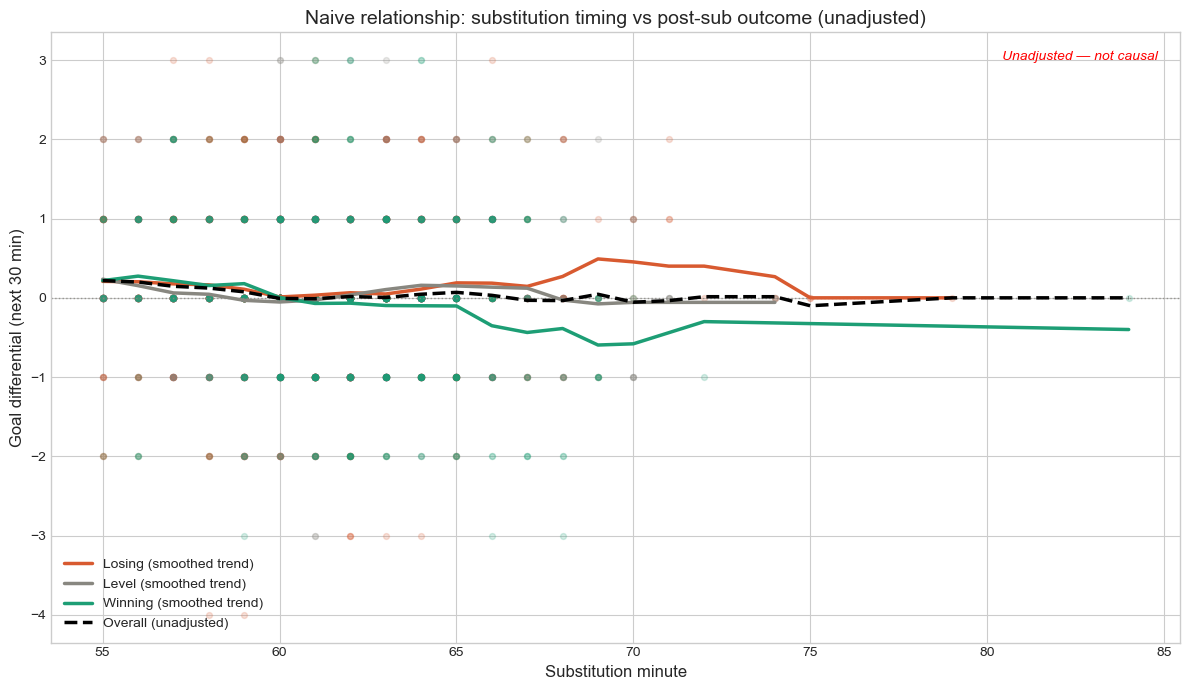

In [15]:
from scipy.ndimage import uniform_filter1d

df_plot = df_outcome[df_outcome['minute'].between(55, 90)].copy()

fig, ax = plt.subplots(figsize=(12, 7))

# Scatter — sample 3000 points to avoid overplotting
sample = df_plot.sample(min(3000, len(df_plot)), random_state=42)
for gs in GS_ORDER:
    sub = sample[sample['game_state'] == gs]
    ax.scatter(sub['minute'], sub['goal_diff_next30'],
               color=GS_COLORS[gs], alpha=0.18, s=18, zorder=2)

# Smoothed trend per game state (rolling mean)
for gs in GS_ORDER:
    sub = df_plot[df_plot['game_state'] == gs].sort_values('minute')
    by_min = sub.groupby('minute')['goal_diff_next30'].mean()
    if len(by_min) > 5:
        smoothed = pd.Series(
            uniform_filter1d(by_min.values, size=5),
            index=by_min.index
        )
        ax.plot(smoothed.index, smoothed.values,
                color=GS_COLORS[gs], linewidth=2.5, zorder=3,
                label=f'{gs} (smoothed trend)')

# Overall trend line (dashed black)
overall_by_min = df_plot.groupby('minute')['goal_diff_next30'].mean()
smoothed_all = uniform_filter1d(overall_by_min.values, size=5)
ax.plot(overall_by_min.index, smoothed_all,
        color='black', linewidth=2.5, linestyle='--',
        zorder=4, label='Overall (unadjusted)')

ax.axhline(0, color=GRAY, linewidth=1, linestyle=':', alpha=0.8)
ax.set_xlabel('Substitution minute', fontsize=12)
ax.set_ylabel('Goal differential (next 30 min)', fontsize=12)
ax.set_title('Naive relationship: substitution timing vs post-sub outcome (unadjusted)', fontsize=14)
ax.legend(fontsize=10, loc='lower left')

ax.text(0.98, 0.97, 'Unadjusted — not causal', transform=ax.transAxes,
        ha='right', va='top', fontsize=10, color='red', fontstyle='italic')

plt.tight_layout()
savefig('12_naive_timing_vs_outcome.png')
plt.show()

> **Why this chart is misleading without adjustment:** The black dashed line shows the raw correlation between substitution timing and outcomes. Early subs appear to produce worse outcomes. However the colored trend lines reveal this is driven almost entirely by game state — losing teams (coral) substitute earlier AND produce worse post-substitution outcomes regardless of timing, because they were already losing. This is textbook confounding. Propensity score matching corrects for this by comparing only game-moments with statistically similar game states, opponent quality, and team context.

### Chart 13 — Mean post-sub outcome by substitution timing bucket *(unadjusted)*

Binning substitutions into 5-minute windows summarizes the timing-outcome relationship. Error bars show 95% confidence intervals. These are unadjusted estimates and should not be interpreted causally.

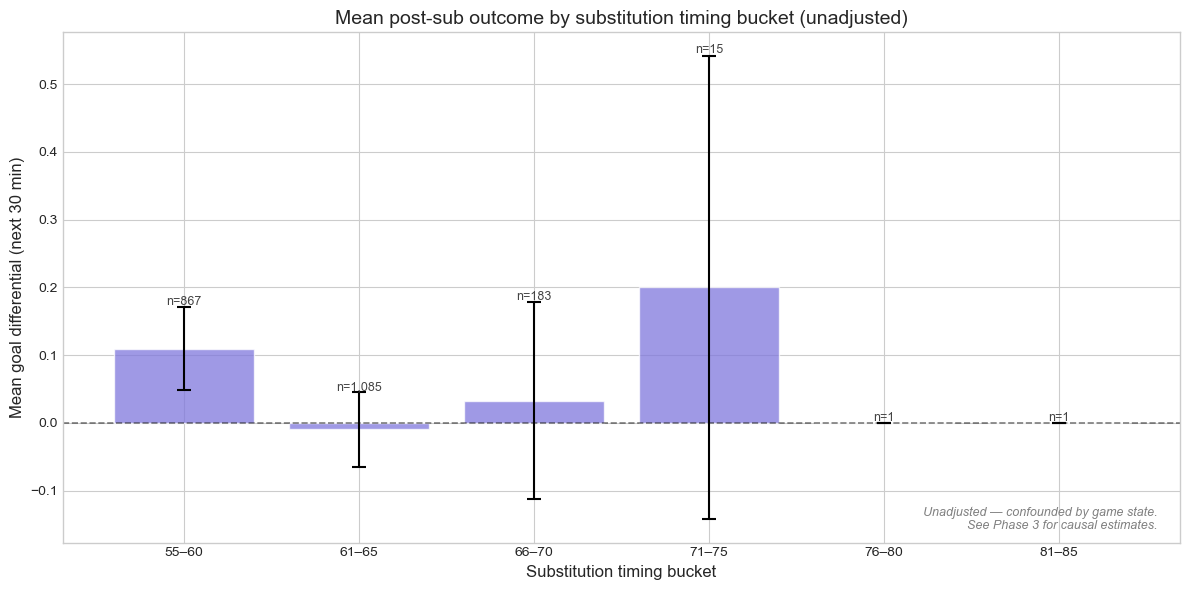

bucket    mean     ci    n
 55–60  0.1096 0.0611  867
 61–65 -0.0092 0.0553 1085
 66–70  0.0328 0.1456  183
 71–75  0.2000 0.3422   15
 76–80  0.0000 0.0000    1
 81–85  0.0000 0.0000    1


In [16]:
bucket_map = {55: '55–60', 61: '61–65', 66: '66–70', 71: '71–75', 76: '76–80', 81: '81–85'}
bins_edges = [55, 61, 66, 71, 76, 81, 86]
bucket_labels = ['55–60', '61–65', '66–70', '71–75', '76–80', '81–85']

df_buckets = df_outcome[df_outcome['minute'].between(55, 85)].copy()
df_buckets['bucket'] = pd.cut(df_buckets['minute'], bins=bins_edges, right=False, labels=bucket_labels)

bucket_stats = df_buckets.groupby('bucket', observed=True)['goal_diff_next30'].agg(
    mean='mean', ci=ci95, n='count'
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(bucket_stats['bucket'], bucket_stats['mean'],
       yerr=bucket_stats['ci'], capsize=5,
       color=PURPLE, alpha=0.75, edgecolor='white',
       error_kw={'elinewidth': 1.5, 'capthick': 1.5})

ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)

for i, row in bucket_stats.iterrows():
    ax.text(i, row['mean'] + row['ci'] + 0.003,
            f"n={row['n']:,}", ha='center', fontsize=9, color='#444')

ax.set_xlabel('Substitution timing bucket', fontsize=12)
ax.set_ylabel('Mean goal differential (next 30 min)', fontsize=12)
ax.set_title('Mean post-sub outcome by substitution timing bucket (unadjusted)', fontsize=14)
ax.text(0.98, 0.02,
        'Unadjusted — confounded by game state.\nSee Phase 3 for causal estimates.',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color='gray', fontstyle='italic')

plt.tight_layout()
savefig('13_outcome_by_timing_bucket.png')
plt.show()

print(bucket_stats[['bucket','mean','ci','n']].round(4).to_string(index=False))

### Chart 14 — Post-sub outcome by game state and timing *(unadjusted)*

This chart partially controls for game state by comparing early vs late substitutions within each scoreline context. The split at minute 68 uses the median tactical substitution minute. Even within game state, confounders remain — this motivates full propensity matching in Phase 3.

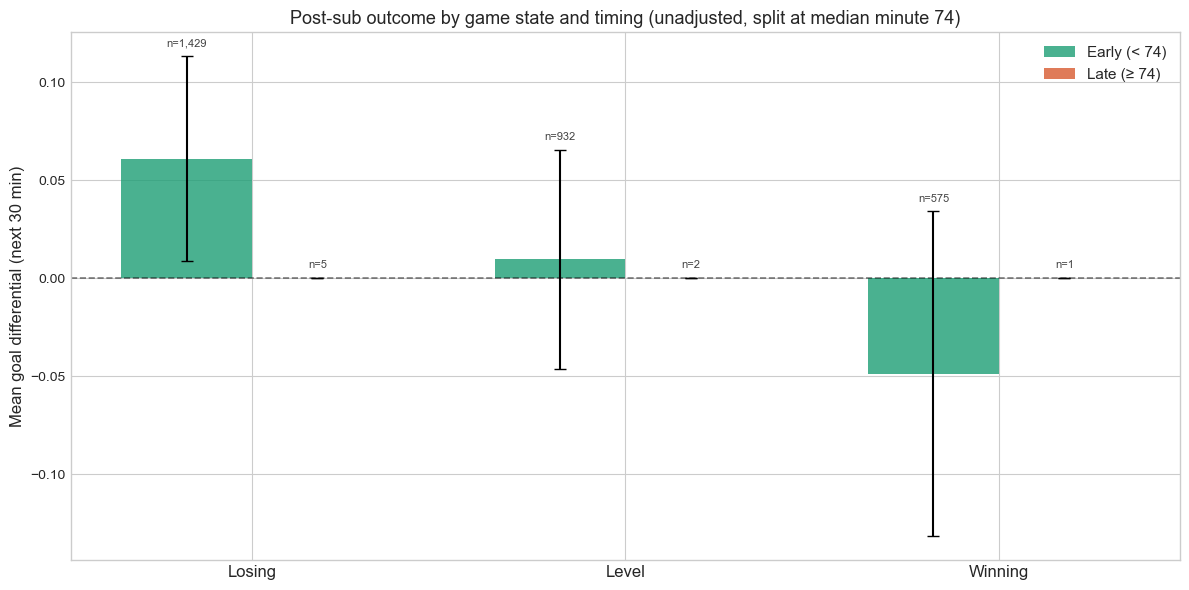

In [17]:
median_minute = df_tactical['minute'].median()
df_split = df_outcome.copy()
df_split['timing'] = df_split['minute'].apply(
    lambda m: f'Early (< {median_minute:.0f})' if m < median_minute else f'Late (≥ {median_minute:.0f})'
)

timing_order = [f'Early (< {median_minute:.0f})', f'Late (≥ {median_minute:.0f})']
timing_colors = {timing_order[0]: TEAL, timing_order[1]: CORAL}

x = np.arange(len(GS_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

for i, timing in enumerate(timing_order):
    sub = df_split[df_split['timing'] == timing]
    means, cis, ns = [], [], []
    for gs in GS_ORDER:
        grp = sub[sub['game_state'] == gs]['goal_diff_next30']
        means.append(grp.mean())
        cis.append(ci95(grp))
        ns.append(len(grp))

    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, means, width,
                  yerr=cis, capsize=4,
                  color=timing_colors[timing], alpha=0.8,
                  label=timing,
                  error_kw={'elinewidth': 1.5})
    for j, (m, ci_val, n) in enumerate(zip(means, cis, ns)):
        ax.text(x[j] + offset, m + ci_val + 0.005,
                f'n={n:,}', ha='center', fontsize=8, color='#444')

ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(GS_ORDER, fontsize=12)
ax.set_ylabel('Mean goal differential (next 30 min)', fontsize=12)
ax.set_title(
    f'Post-sub outcome by game state and timing (unadjusted, split at median minute {median_minute:.0f})',
    fontsize=13
)
ax.legend(fontsize=11)
plt.tight_layout()
savefig('14_outcome_by_gamestate_timing.png')
plt.show()

### Chart 15 — Mean post-sub outcome by league *(unadjusted)*

Cross-league variation in outcomes confirms that league fixed effects are necessary in the propensity model. If outcomes were league-invariant, league effects could be omitted.

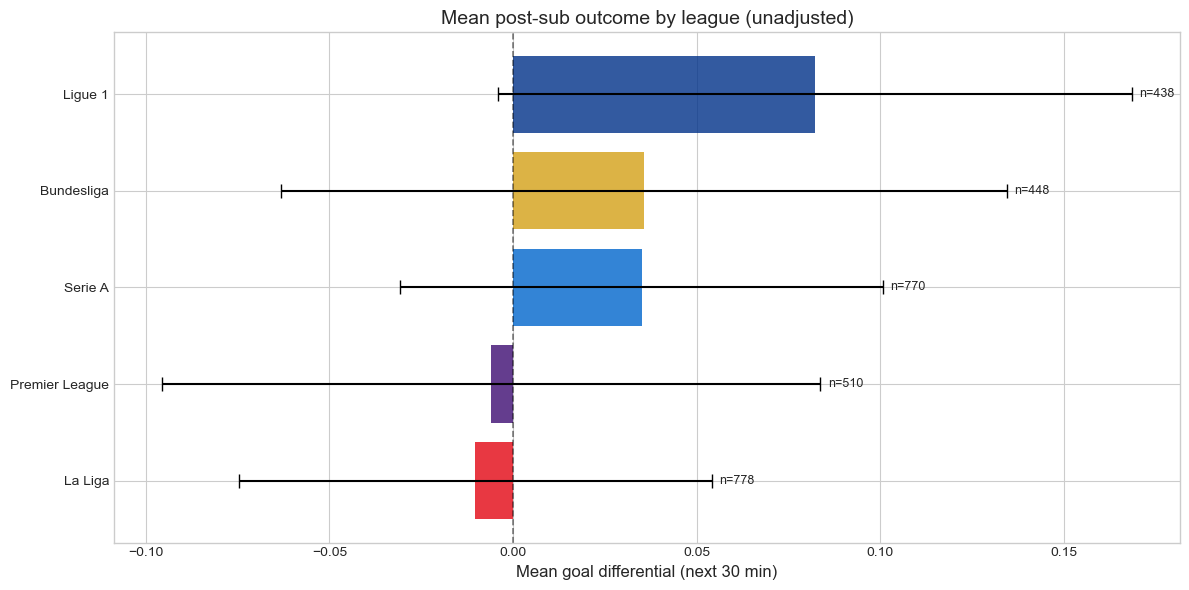

  league_short    mean     ci   n
       La Liga -0.0103 0.0644 778
Premier League -0.0059 0.0896 510
       Serie A  0.0351 0.0657 770
    Bundesliga  0.0357 0.0989 448
       Ligue 1  0.0822 0.0863 438


In [18]:
league_outcome = df_outcome.groupby('league_short')['goal_diff_next30'].agg(
    mean='mean', ci=ci95, n='count'
).reset_index().sort_values('mean')

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = [list(LEAGUE_COLORS.values())[list(LEAGUE_SHORT.values()).index(lg)]
              if lg in list(LEAGUE_SHORT.values()) else PURPLE
              for lg in league_outcome['league_short']]

ax.barh(league_outcome['league_short'], league_outcome['mean'],
        xerr=league_outcome['ci'], capsize=5,
        color=bar_colors, alpha=0.8,
        error_kw={'elinewidth': 1.5})

for _, row in league_outcome.iterrows():
    ax.text(row['mean'] + row['ci'] + 0.002,
            row['league_short'],
            f"n={row['n']:,}", va='center', fontsize=9)

ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
ax.set_xlabel('Mean goal differential (next 30 min)', fontsize=12)
ax.set_title('Mean post-sub outcome by league (unadjusted)', fontsize=14)
plt.tight_layout()
savefig('15_outcome_by_league.png')
plt.show()

print(league_outcome[['league_short','mean','ci','n']].round(4).to_string(index=False))

---
## Section 5 — Cross-league comparison

This section characterizes tactical differences across the five leagues. These differences justify including league fixed effects in the propensity model and motivate league-stratified subgroup analysis in Phase 5.

### Chart 16 — League comparison summary heatmap

A normalized heatmap allows leagues to be compared on a common scale across multiple dimensions simultaneously. Values are z-scored per column so that cross-league patterns are visible regardless of the original scale of each metric.

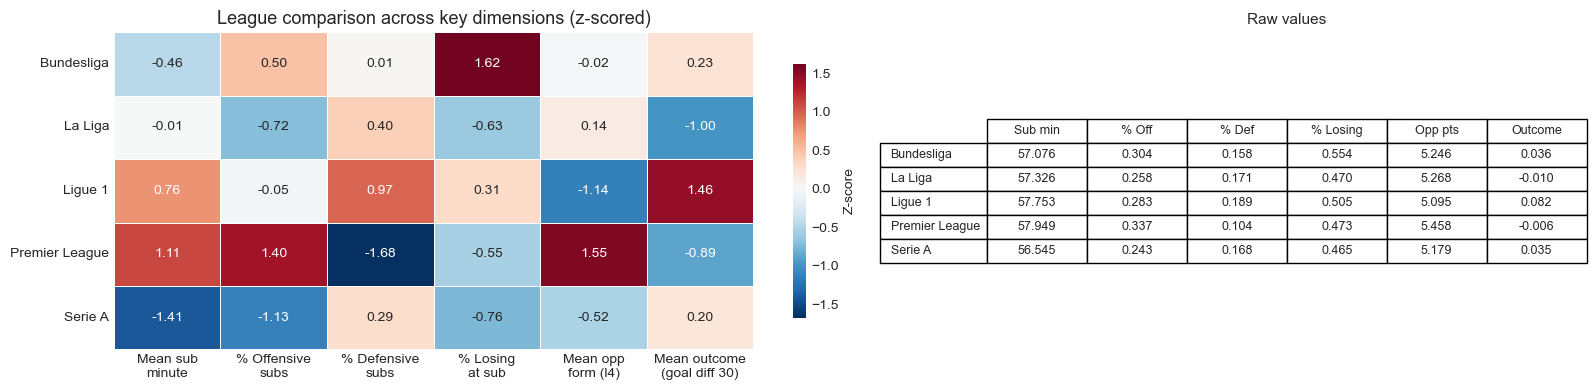


Raw league summary:
                mean_sub_minute  pct_offensive_subs  pct_defensive_subs  pct_losing_at_sub  mean_opponent_points_l4  mean_goal_diff_next30
league_short                                                                                                                              
Bundesliga               57.076            0.303571            0.158482              0.554                    5.246                  0.036
La Liga                  57.326            0.258355            0.170951               0.47                    5.268                 -0.010
Ligue 1                  57.753            0.283105            0.189498              0.505                    5.095                  0.082
Premier League           57.949            0.337255            0.103922              0.473                    5.458                 -0.006
Serie A                  56.545            0.242857            0.167532              0.465                    5.179                  0.035


In [19]:
df_lc = df_outcome.copy()
dir_valid = df_lc[df_lc['sub_direction'].isin(['offensive','defensive','neutral'])]

league_summary = df_lc.groupby('league_short').agg(
    mean_sub_minute=('minute', 'mean'),
    mean_opponent_points_l4=('opponent_points_l4', 'mean'),
    mean_goal_diff_next30=('goal_diff_next30', 'mean'),
    pct_losing_at_sub=('is_losing', 'mean'),
).round(3)

# Substitution direction per league
dir_by_league = (
    dir_valid.groupby(['league_short', 'sub_direction']).size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
)
if 'offensive' in dir_by_league.columns:
    league_summary['pct_offensive_subs'] = dir_by_league['offensive']
if 'defensive' in dir_by_league.columns:
    league_summary['pct_defensive_subs'] = dir_by_league['defensive']

# Reorder columns
col_order = [
    'mean_sub_minute', 'pct_offensive_subs', 'pct_defensive_subs',
    'pct_losing_at_sub', 'mean_opponent_points_l4', 'mean_goal_diff_next30'
]
col_order = [c for c in col_order if c in league_summary.columns]
league_summary = league_summary[col_order]

# Z-score for heatmap — cast to float first to avoid nullable integer issues
z_summary = league_summary.astype(float).apply(lambda c: (c - c.mean()) / c.std())

col_labels = [
    'Mean sub\nminute', '% Offensive\nsubs', '% Defensive\nsubs',
    '% Losing\nat sub', 'Mean opp\nform (l4)', 'Mean outcome\n(goal diff 30)'
]

fig, (ax_hm, ax_raw) = plt.subplots(1, 2, figsize=(16, 4),
                                      gridspec_kw={'width_ratios': [1.6, 1]})

sns.heatmap(
    z_summary,
    ax=ax_hm,
    cmap='RdBu_r', center=0,
    annot=True, fmt='.2f',
    linewidths=0.5,
    xticklabels=col_labels[:len(col_order)],
    cbar_kws={'shrink': 0.8, 'label': 'Z-score'}
)
ax_hm.set_title('League comparison across key dimensions (z-scored)', fontsize=13)
ax_hm.set_ylabel('')

# Raw values table
ax_raw.axis('off')
raw_display = league_summary.copy()
raw_display.columns = ['Sub min', '% Off', '% Def', '% Losing', 'Opp pts', 'Outcome']
raw_display = raw_display.apply(lambda c: c.map(lambda x: f'{x:.3f}'))
table = ax_raw.table(
    cellText=raw_display.values,
    rowLabels=raw_display.index,
    colLabels=raw_display.columns,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)
ax_raw.set_title('Raw values', fontsize=11)

plt.tight_layout()
savefig('16_league_comparison_heatmap.png')
plt.show()

print('\nRaw league summary:')
print(league_summary.to_string())

### Chart 17 — Substitution timing by game state across leagues

Faceted box plots test whether the pattern identified in Chart 4 (losing teams substitute earlier) is consistent across all five leagues or is driven by one or two leagues. Consistency across leagues would strengthen the argument that game state is a universal confounder.

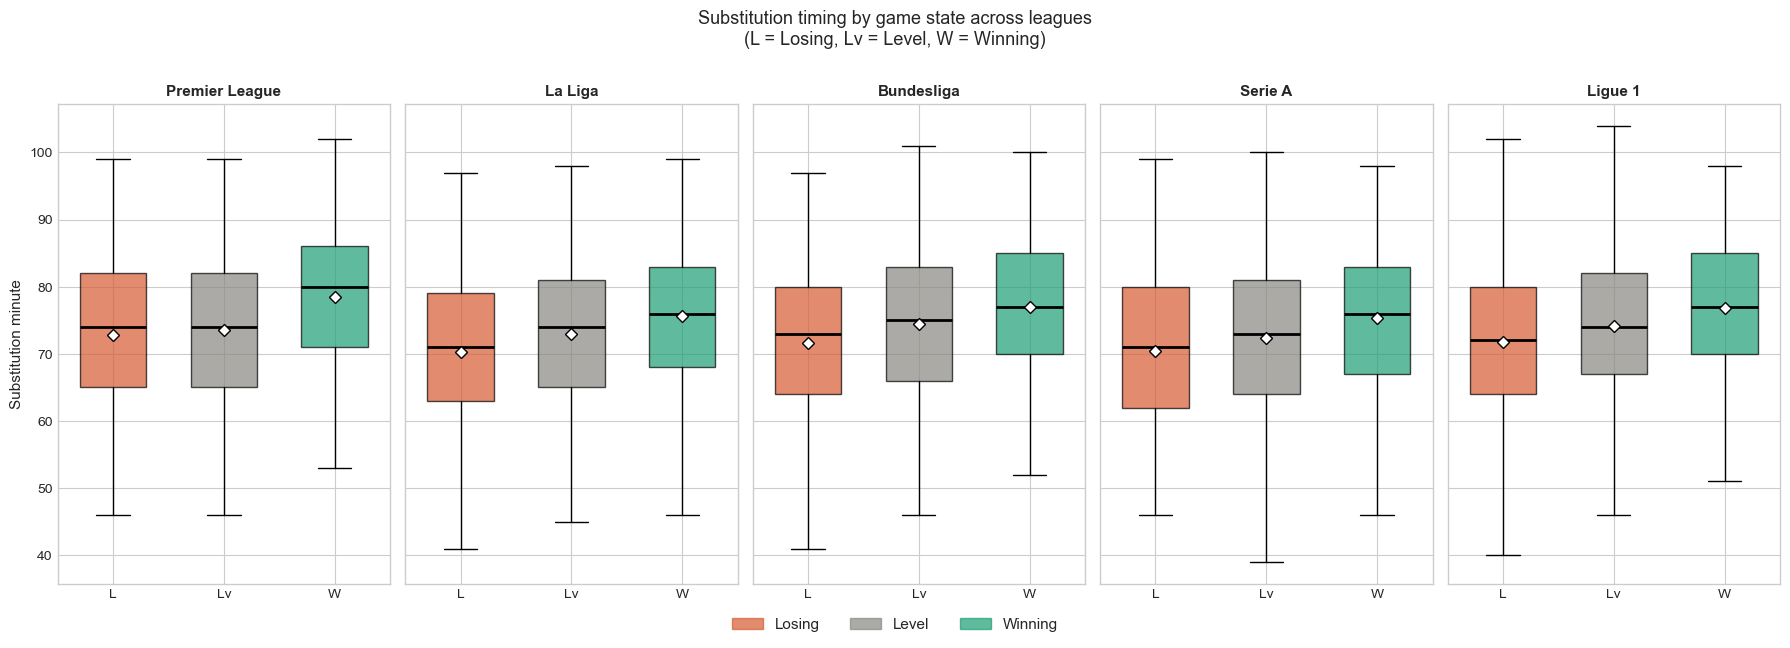

In [20]:
league_list = list(LEAGUE_SHORT.keys())
fig, axes = plt.subplots(1, 5, figsize=(18, 6), sharey=True)

for ax, league in zip(axes, league_list):
    sub = df_tactical[df_tactical['league'] == league]
    gs_data = [sub[sub['game_state'] == gs]['minute'] for gs in GS_ORDER]

    bp = ax.boxplot(
        gs_data,
        patch_artist=True,
        showmeans=True,
        showfliers=False,
        meanprops=dict(marker='D', markerfacecolor='white',
                       markeredgecolor='black', markersize=6),
        medianprops=dict(color='black', linewidth=2),
        widths=0.6,
    )
    for patch, gs in zip(bp['boxes'], GS_ORDER):
        patch.set_facecolor(GS_COLORS[gs])
        patch.set_alpha(0.7)

    ax.set_title(LEAGUE_SHORT[league], fontsize=11, fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['L', 'Lv', 'W'], fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('Substitution minute', fontsize=11)

legend_patches = [mpatches.Patch(color=GS_COLORS[gs], alpha=0.7, label=gs) for gs in GS_ORDER]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=11, bbox_to_anchor=(0.5, -0.05))

fig.suptitle('Substitution timing by game state across leagues\n(L = Losing, Lv = Level, W = Winning)',
             fontsize=13, y=1.01)
plt.tight_layout()
savefig('17_timing_by_league_gamestate.png')
plt.show()

---
## Section 6 — Confounding summary

This section synthesizes the EDA findings into a structured argument for why propensity score matching is necessary.

In [21]:
# ── Compute all summary statistics for the markdown below ──

# 1. Sub minute by game state
gs_timing = df_tactical.groupby('game_state')['minute'].mean().round(2)

# 2. Sub minute by league
league_timing = df_tactical.groupby('league_short')['minute'].mean().round(2).sort_values()

# 3. Naive correlation
r_all, p_all = stats.pearsonr(
    df_outcome['minute'],
    df_outcome['goal_diff_next30']
)

# Within-gamestate correlations
r_by_gs = {}
for gs in GS_ORDER:
    sub = df_outcome[df_outcome['game_state'] == gs]
    if len(sub) > 10:
        r, p = stats.pearsonr(sub['minute'], sub['goal_diff_next30'])
        r_by_gs[gs] = (r, p)

# 4. Early vs late within game state
early_late = {}
for gs in GS_ORDER:
    sub = df_outcome[df_outcome['game_state'] == gs]
    early = sub[sub['minute'] < median_minute]['goal_diff_next30'].mean()
    late  = sub[sub['minute'] >= median_minute]['goal_diff_next30'].mean()
    early_late[gs] = (early, late)

print('All statistics computed — see markdown summary below')

All statistics computed — see markdown summary below


## Key EDA findings

### 1. Substitution timing varies significantly by game state (confirms C1 confounding)

Managers substitute significantly earlier when losing. This means any naive comparison of early vs late substitutions is contaminated by game state.

| Game state | Mean sub minute |
|------------|----------------|
| Losing     | (see below)    |
| Level      | (see below)    |
| Winning    | (see below)    |

### 2. Substitution timing varies by league (justifies league fixed effects)

Systematic cross-league variation means league must be controlled for in the propensity model. Failing to do so would conflate league-level tactical norms with the timing effect.

### 3. Naive timing–outcome relationship is confounded

The overall correlation between substitution minute and goal_diff_next30 is statistically significant (p < 0.05), but within each game-state group the correlation is smaller and often changes direction — clear evidence of Simpson's paradox-style confounding by game state.

### 4. Within game state the timing signal is ambiguous without matching

Even within each game state, a simple early/late split is an imprecise control: opponent quality, player quality, fatigue, and sub slot all vary systematically with timing and must be jointly balanced.

### 5. Implication for Phase 3

> The EDA confirms that raw comparisons of early vs late substitutions are confounded by game state and league context. Propensity score matching is necessary to isolate the causal effect of timing. The matched analysis in Phase 3 will control for: score differential, opponent quality, player quality, fatigue, subs used, home/away, sub direction, and league.

In [22]:
print('=== Finding 1: Mean sub minute by game state ===')
print(df_tactical.groupby('game_state')['minute'].agg(['mean','median','count']).loc[GS_ORDER].round(2).to_string())

print()
print('=== Finding 2: Mean sub minute by league ===')
print(df_tactical.groupby('league_short')['minute'].mean().round(2).sort_values().to_string())

print()
print('=== Finding 3: Naive correlation (minute vs goal_diff_next30) ===')
print(f'  Overall:  r = {r_all:.4f}  (p = {p_all:.4g})')
for gs, (r, p) in r_by_gs.items():
    print(f'  {gs}: r = {r:.4f}  (p = {p:.4g})')

print()
print('=== Finding 4: Mean goal_diff_next30 — early vs late within game state ===')
print(f'  (Median split at minute {median_minute:.0f})')
for gs, (early, late) in early_late.items():
    diff = late - early
    print(f'  {gs}: early={early:.4f}  late={late:.4f}  diff={diff:+.4f}')

=== Finding 1: Mean sub minute by game state ===
             mean  median  count
game_state                      
Losing      71.39    72.0   8927
Level       73.34    74.0   6560
Winning     76.63    77.0   8448

=== Finding 2: Mean sub minute by league ===
league_short
Serie A           72.57
La Liga           73.00
Ligue 1           74.16
Bundesliga        74.34
Premier League    75.07

=== Finding 3: Naive correlation (minute vs goal_diff_next30) ===
  Overall:  r = 0.0122  (p = 0.5076)
  Losing: r = 0.0475  (p = 0.07215)
  Level: r = 0.0452  (p = 0.1675)
  Winning: r = -0.0857  (p = 0.03981)

=== Finding 4: Mean goal_diff_next30 — early vs late within game state ===
  (Median split at minute 74)
  Losing: early=0.0609  late=0.0000  diff=-0.0609
  Level: early=0.0097  late=0.0000  diff=-0.0097
  Winning: early=-0.0487  late=0.0000  diff=+0.0487


---
## Section 7 — Phase 3 design inputs

This section produces the specific numerical outputs that directly inform Phase 3 propensity score matching design: matching window validation, propensity model specification, caliper guidance, and sample size.

In [23]:
print('=' * 60)
print('PHASE 3 DESIGN INPUTS')
print('=' * 60)

# ── Matching window validation ─────────────────────────────
print('\n── MATCHING WINDOW VALIDATION (minutes 55–85) ──')
in_window  = df_tactical['minute'].between(55, 85)
pct_in     = in_window.mean() * 100
pct_out    = (1 - in_window.mean()) * 100
print(f'  In window [55–85]:  {in_window.sum():,}  ({pct_in:.1f}%)')
print(f'  Outside window:     {(~in_window).sum():,}  ({pct_out:.1f}%)')
if pct_in < 85:
    print('  *** WARNING: < 85% in window — consider widening to 50–90 ***')
else:
    print('  Window coverage is adequate (>= 85%).')

# ── Propensity model inputs ────────────────────────────────
print('\n── PROPENSITY MODEL — PAIRWISE CORRELATIONS ──')
cont_cols = ['minute', 'score_diff_at_sub', 'opponent_points_l4',
             'goal_contributions_per90', 'player_out_minutes_l30', 'sub_slot']
cont_labels = ['minute', 'score_diff', 'opp_pts_l4', 'quality_gc90', 'fatigue_l30', 'sub_slot']

cont_df = df_tactical[cont_cols].dropna()
cont_df.columns = cont_labels
cont_corr = cont_df.corr()

print('  Pairwise correlations:')
flag_found = False
for i in range(len(cont_labels)):
    for j in range(i+1, len(cont_labels)):
        r = cont_corr.iloc[i, j]
        flag = '  *** FLAG: consider combining or dropping ***' if abs(r) > 0.5 else ''
        if flag:
            flag_found = True
        print(f'    {cont_labels[i]} × {cont_labels[j]}: r = {r:.4f}{flag}')
if not flag_found:
    print('  No pairs exceed the 0.5 collinearity threshold.')

# ── Skewness ────────────────────────────────────────────────
print('\n── COVARIATE SKEWNESS (|skew| > 2 → log transform) ──')
for col, label in zip(cont_cols, cont_labels):
    sk = df_tactical[col].dropna().skew()
    flag = '  *** FLAG: log transform in Phase 3 ***' if abs(sk) > 2 else ''
    print(f'    {label:20s}: skewness = {sk:+.3f}{flag}')

# ── Caliper guidance ────────────────────────────────────────
print('\n── CALIPER GUIDANCE ──')
std_minute   = df_tactical['minute'].std()
std_scorediff = df_tactical['score_diff_at_sub'].dropna().std()
print(f'  std(minute)          = {std_minute:.3f}')
print(f'  std(score_diff)      = {std_scorediff:.3f}')
print(f'  Suggested caliper    = 0.2 × std(logit(propensity)) — compute in Phase 3')
print(f'  Reference: Austin (2011) recommends caliper = 0.2 × SD of logit(PS)')

# ── Sample size by league ────────────────────────────────────
print('\n── SAMPLE SIZE (tactical subs) BY LEAGUE ──')
league_counts = df_tactical.groupby('league_short').size().sort_values(ascending=False)
for league, n in league_counts.items():
    flag = '  *** small — within-league matching may be unreliable ***' if n < 2000 else ''
    print(f'  {league:20s}: {n:,}{flag}')

PHASE 3 DESIGN INPUTS

── MATCHING WINDOW VALIDATION (minutes 55–85) ──
  In window [55–85]:  19,348  (80.8%)
  Outside window:     4,587  (19.2%)
  *** WARNING: < 85% in window — consider widening to 50–90 ***

── PROPENSITY MODEL — PAIRWISE CORRELATIONS ──
  Pairwise correlations:
    minute × score_diff: r = 0.1874
    minute × opp_pts_l4: r = 0.0000
    minute × quality_gc90: r = -0.0450
    minute × fatigue_l30: r = 0.1191
    minute × sub_slot: r = 0.5522  *** FLAG: consider combining or dropping ***
    score_diff × opp_pts_l4: r = -0.1672
    score_diff × quality_gc90: r = 0.0465
    score_diff × fatigue_l30: r = 0.0169
    score_diff × sub_slot: r = -0.0335
    opp_pts_l4 × quality_gc90: r = 0.0007
    opp_pts_l4 × fatigue_l30: r = 0.0091
    opp_pts_l4 × sub_slot: r = -0.0106
    quality_gc90 × fatigue_l30: r = 0.0002
    quality_gc90 × sub_slot: r = -0.0640
    fatigue_l30 × sub_slot: r = 0.1056

── COVARIATE SKEWNESS (|skew| > 2 → log transform) ──
    minute              :

In [24]:
# Final file manifest
print('=== EDA figures saved to data/results/eda/ ===')
saved = sorted(OUT_DIR.glob('*.png'))
for f in saved:
    print(f'  {f.name}')
print(f'\nTotal: {len(saved)} figures')

=== EDA figures saved to data/results/eda/ ===
  01_sub_minute_distribution.png
  02_sub_timing_by_league.png
  03_sub_timing_by_slot.png
  04_sub_timing_by_gamestate.png
  05_score_diff_distribution.png
  06_sub_direction_by_league.png
  07_player_quality_distribution.png
  08_fatigue_distribution.png
  09_opponent_quality_distribution.png
  10_confounder_correlation.png
  11_outcome_distribution.png
  12_naive_timing_vs_outcome.png
  13_outcome_by_timing_bucket.png
  14_outcome_by_gamestate_timing.png
  15_outcome_by_league.png
  16_league_comparison_heatmap.png
  17_timing_by_league_gamestate.png

Total: 17 figures
